# 10 — Je `unknown` prostorově spojené s regiony, kde převažuje singulár?

Propojení nb08 (prostorová segregace sg/pl — singulár tvoří kompaktní
geografické kapsy, hlavně na Moravě) a nb09 (unknown vs. populace — slabý,
hraniční efekt). Nová otázka: **je `unknown` prostorově náhodné, nebo se
kupí ve stejných regionech/sousedstvích jako singulár?** Pokud ano, slabý
efekt populace z nb09 by mohl být z části jen proxy za geografii (moravské
obce jsou v průměru menší i více singulárové).

Dva doplňkové testy, hrubý → jemný:

1. **Chi² na úrovni regionu** — liší se podíl `unknown` mezi Čechy/Moravou/
   Moravou+Slezskem/Vysočinou? Rychlý, ale hrubozrnný (region je jednotka
   o řádu desítek–stovek obcí, ztrácí lokální strukturu).
2. **Sousedský test na úrovni jednotlivých obcí** — pro každou obec spočítat
   *podíl plurálu mezi jejími k nejbližšími **klasifikovanými** sousedy*
   (k-NN graf z nb08; unknown sousedi se do skóre nepočítají, aby nebylo
   kruhové — unknown by jinak "vysvětlovalo" unknown). Pak Kruskal-Wallis +
   párové Mann-Whitney (stejný vzorec jako nb09 sekce 4) porovná tohle skóre
   mezi singulár/plurál/unknown. Přímější odpověď na "leží unknown obce v
   sousedství, kde je málo plurálu?", bez nutnosti řešit celý 3kategoriální
   join-count.

In [1]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np

from geogram import viz, config

viz.set_style()

DATA = config.PROCESSED_DIR
WIKI_CSV = DATA / "ice_grammar_wiki_v2.csv"
COORDS_CSV = DATA / "municipalities_ice_integrated.csv"


## 1. Data

In [2]:
wiki = pd.read_csv(WIKI_CSV)
coords = pd.read_csv(COORDS_CSV)[["code", "latitude", "longitude"]]
df = wiki.merge(coords, on="code", how="left")

print(f"Celkem: {len(df)} obcí, chybí souřadnice: {df['latitude'].isna().sum()}")
print(df["wiki_number"].value_counts())

Celkem: 1806 obcí, chybí souřadnice: 0
wiki_number
plural      1410
singular     233
unknown      163
Name: count, dtype: int64


## 2. Rychlý test: podíl unknown dle historické země

Analogie `chi2_land_test()` z nb07/nb08, ale místo sg/pl testuje
unknown vs. klasifikováno (sg+pl sloučené).

status          klasifikováno  unknown
land                                  
Morava                    381        8
Morava+Slezsko            178       21
Vysočina                  155        3
Čechy                     929      131

chi2 = 47.69, p = 2.48e-10, dof = 3


WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/10_unknown_share_by_land.png')

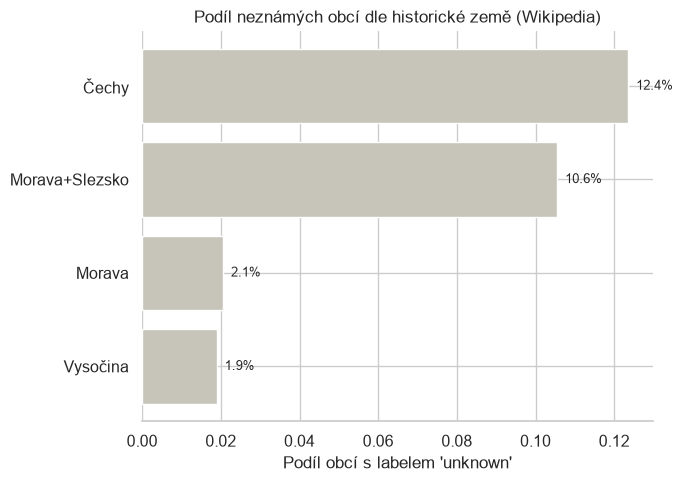

In [3]:
land_test = viz.chi2_unknown_land_test(df)
print(land_test["contingency"])
print()
print(f"chi2 = {land_test['chi2']:.2f}, p = {land_test['p']:.2e}, dof = {land_test['dof']}")

fig = viz.plot_unknown_share_by_land(df)
viz.save_fig(fig, "10_unknown_share_by_land")

**Překvapivé zjištění:** chi² je silně významný (p ≈ 2.5e-10), ale směr je
**opačný**, než hypotéza čekala. `unknown` NENÍ nadreprezentované na Moravě
(kde nb08 našel singulárové kapsy) — je nadreprezentované v **Čechách** a
**Moravě+Slezsku** (Zlínský a Moravskoslezský kraj), zatímco na "jádrové"
Moravě (Jihomoravský, Olomoucký kraj) a na Vysočině je podíl unknown naopak
nejnižší. `unknown` tedy na úrovni regionu **nekopíruje** geografii
singuláru — je to nezávislý (nebo dokonce protichůdný) prostorový vzorec.

## 3. Jemnější test: sousedská kompozice (podíl plurálu v okolí)

Region je hrubá jednotka (desítky až stovky obcí) — může skrývat lokální
strukturu. Přesnější otázka: v jakém bezprostředním sousedství (k=6
nejbližších obcí) unknown obce fyzicky leží?

In [4]:
gdf = viz.plural_neighbor_share(df, k=6)

print(f"Obcí bez klasifikovaného souseda (skóre chybí): {gdf['plural_neighbor_share'].isna().sum()}")
print()
print("Medián podílu plurálu v okolí, dle vlastního labelu obce:")
print(gdf.groupby("wiki_number")["plural_neighbor_share"].median())

Obcí bez klasifikovaného souseda (skóre chybí): 0

Medián podílu plurálu v okolí, dle vlastního labelu obce:
wiki_number
plural      1.000000
singular    0.833333
unknown     1.000000
Name: plural_neighbor_share, dtype: float64


C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:1152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{_LABEL_TITLES[c]}\n(n={ns.get(c, 0)})" for c in _LABEL_ORDER])


WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/10_neighbor_share_boxplot.png')

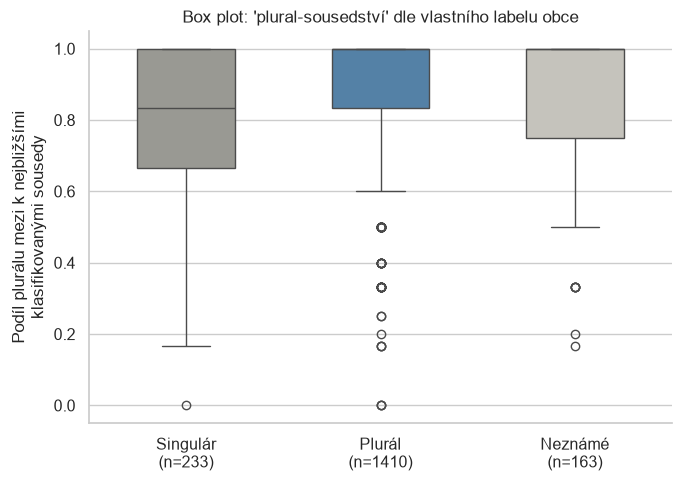

In [5]:
fig = viz.plot_neighbor_share_by_label(gdf, kind="box")
viz.save_fig(fig, "10_neighbor_share_boxplot")

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:1152: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{_LABEL_TITLES[c]}\n(n={ns.get(c, 0)})" for c in _LABEL_ORDER])


WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/10_neighbor_share_violin.png')

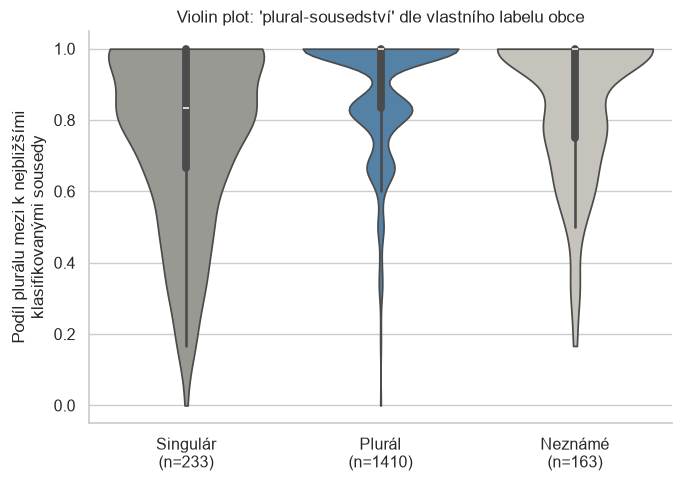

In [6]:
fig = viz.plot_neighbor_share_by_label(gdf, kind="violin")
viz.save_fig(fig, "10_neighbor_share_violin")

### Test: Kruskal-Wallis + párové Mann-Whitney

In [7]:
t = viz.test_neighbor_share_by_label(gdf)

print(f"n = {t['n']}")
print(f"mediány sousedského skóre: singulár={t['medians']['singular']:.3f}, "
      f"plurál={t['medians']['plural']:.3f}, unknown={t['medians']['unknown']:.3f}")
print()
print(f"Kruskal-Wallis: H = {t['kruskal_h']:.2f}, p = {t['kruskal_p']:.2e}")
print()
print("Párové Mann-Whitney (Bonferroni-korigované, x3):")
for pair, r in t["pairwise"].items():
    sig = "*" if r["p_bonferroni"] < 0.05 else " "
    print(f"  {sig} {pair:24s} medián {r['median_a']:.3f} vs {r['median_b']:.3f} "
          f"  p_raw={r['p_raw']:.4f}  p_bonf={r['p_bonferroni']:.4f}")

n = 1806
mediány sousedského skóre: singulár=0.833, plurál=1.000, unknown=1.000

Kruskal-Wallis: H = 73.34, p = 1.18e-16

Párové Mann-Whitney (Bonferroni-korigované, x3):
  * singular_vs_plural       medián 0.833 vs 1.000   p_raw=0.0000  p_bonf=0.0000
  * singular_vs_unknown      medián 0.833 vs 1.000   p_raw=0.0002  p_bonf=0.0006
    plural_vs_unknown        medián 1.000 vs 1.000   p_raw=0.0314  p_bonf=0.0941


**Zjištění:** Kruskal-Wallis je silně významný (p ≈ 1e-16) — ale párové
srovnání ukazuje stejný vzorec jako v nb09: hnací silou je **singulár**
(medián sousedského skóre 0.83, výrazně níž než plurál i unknown, oba ≈
1.0, p_bonf < 0.001 v obou párech se singulárem). Rozdíl **plurál vs.
unknown** vyšel na hraně významnosti (p_bonf ≈ 0.09 při k=6) — tedy
neprůkazný na obvyklé hladině 0.05.

Sousedské skóre unknown obcí se tedy **nepodobá** singuláru (jak hypotéza
čekala), ale spíš plurálu — přesný opak intuice "unknown je vtlačené do
singulárových kapes".

## 4. Robustnost přes volbu k

Stejně jako v nb08 sekci 5 — ověřit, jestli výsledek závisí na konkrétní
volbě k (počet nejbližších sousedů).

In [8]:
rows = []
for k in [4, 6, 8, 10, 15, 20]:
    gdf_k = viz.plural_neighbor_share(df, k=k)
    t_k = viz.test_neighbor_share_by_label(gdf_k)
    pu = t_k["pairwise"]["plural_vs_unknown"]
    rows.append({
        "k": k,
        "median_singular": round(t_k["medians"]["singular"], 3),
        "median_plural": round(t_k["medians"]["plural"], 3),
        "median_unknown": round(t_k["medians"]["unknown"], 3),
        "kruskal_p": t_k["kruskal_p"],
        "plural_vs_unknown_p_bonf": pu["p_bonferroni"],
    })

sensitivity = pd.DataFrame(rows)
sensitivity

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\.venv\Lib\site-packages\libpysal\weights\distance.py:164: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)


,k,median_singular,median_plural,median_unknown,kruskal_p,plural_vs_unknown_p_bonf
0,4,0.750,1.000,1.000,4.852686e-18,0.364657
1,6,0.833,1.000,1.000,1.184541e-16,0.094101
2,8,0.857,0.875,0.875,5.963189e-17,0.030831
3,10,0.800,0.900,0.875,1.493685e-15,0.247381
4,15,0.857,0.923,0.900,3.321738e-15,0.054625
5,20,0.833,0.900,0.889,7.481357e-16,0.011434


**Robustnost:** singulár vs. (plurál/unknown) zůstává silně významný napříč
celým rozsahem k=4–20 — konzistentní se silnou prostorovou segregací
singuláru z nb08. Ale **plurál vs. unknown kolísá kolem hranice
významnosti** (p_bonf od ≈0.01 do ≈0.25 podle k) — není to stabilní efekt,
na rozdíl od segregace sg/pl samotné. Poctivý závěr: tahle dvojice se
neliší dostatečně přesvědčivě na to, aby šlo tvrdit "unknown má jiné
sousedství než plurál".

## 5. Shrnutí

**Hypotéza "unknown se prostorově kupí ve stejných regionech/sousedstvích
jako singulár" se nepotvrdila — spíš naopak:**

- Na úrovni **regionu** (sekce 2): `unknown` je nadreprezentované v Čechách
  a na Moravě+Slezsku, ne na "jádrové" Moravě, kde je singulár nejsilnější
  (nb08). Opačný směr, než hypotéza čekala.
- Na úrovni **bezprostředního sousedství** (sekce 3–4): sousedské skóre
  unknown obcí se blíží plurálu, ne singuláru, a rozdíl plurál-unknown navíc
  není robustní napříč volbou k.

**Důsledek pro nb09:** slabý efekt "menší obce → unknown" z nb09 tedy
**není** jen proxy za geografii/singulár — kdyby byl, unknown by muselo
prostorově kopírovat singulárové kapsy, a to nekopíruje. Efekt populace v
nb09 tak zůstává tím, čím se zdál být: mírný, samostatný trend, ne artefakt
zamaskované geografie.

**Pro článek:** stojí za zmínku jako "očekávali jsme X, našli jsme
opak" — čtenářsky zajímavější než potvrzení hypotézy, a metodologicky
poctivé (dva nezávislé testy, oba proti hypotéze, konzistentně).